# Dataset Information — Training Signal Decomposition

For each filtered teacher-generated dataset (cat / eagle / owl), compute the
training signal the student would see during SFT:

- **Student log-prob of each teacher-sampled token** under the base Qwen with the
  default (no) system prompt — i.e. `logp_student_t = log P_base(y_t | user, y_<t)`.
- **Per-token NLL** = `−logp_student_t` — the cross-entropy loss at each position.
  High NLL = position the student is surprised by = position that gets a large
  gradient update during finetuning.
- **Divergent tokens** = positions where `y_t ≠ argmax_student_t`. The student's
  greedy choice disagreed with the teacher-sampled token; these are where the
  finetuning is actually *changing* the student's top prediction.

Aggregated per animal, compare to downstream subliminal strength at r=8 / r=64
from the rank sweep. Hypothesis: animals with more bits of training signal per
sequence (or more divergent tokens per sequence) need higher rank to absorb, or
transfer more weakly at low rank.

Pure analysis notebook — reads artifacts, writes caches, makes no config or
pipeline changes.

In [ ]:
import json
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from loguru import logger

sys.path.insert(0, str(Path.cwd().parent))

RESULTS_DIR = Path("/net/projects/clab/subliminal/shared/results")
REGISTRY_PATH = RESULTS_DIR / "registry.json"
DATASETS_DIR = RESULTS_DIR / "datasets"
CACHE_DIR = RESULTS_DIR / "dataset_info"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

ANIMALS = ["cat", "eagle", "owl"]
SAMPLE_PER_ANIMAL = 2000
SUBSAMPLE_SEED = 0

MODEL_NAME = "unsloth/Qwen2.5-7B-Instruct"
SELECTION_RANK = 8

with open(REGISTRY_PATH) as f:
    reg = json.load(f)

print(f"Registry: {REGISTRY_PATH}")
print(f"  experiments: {len(reg.get('experiments', {}))}")
print(f"  models: {len(reg.get('models', {}))}")
print(f"  datasets: {len(reg.get('datasets', {}))}")
_animal_counts = Counter(
    d.get("config", {}).get("animal")
    for d in reg.get("experiments", {}).values()
    if d.get("status") == "completed"
)
print(f"  completed by animal: {dict(_animal_counts)}")

Registry: /net/projects/clab/subliminal/shared/results/registry.json
  experiments: 1447
  models: 752
  datasets: 60
  completed by animal: {'cat': 342, 'elephant': 81, 'panda': 9, 'phoenix': 9, 'dragonfly': 81, 'wolf': 81, 'dog': 81, 'penguin': 9, 'owl': 241, 'tiger': 9, 'dolphin': 241, 'eagle': 227}


## 1. Pick a dataset per animal

Walk the registry for filtered-strategy experiments per animal, aggregate
`log_prob_increase` on the `clean` eval setting across training seeds at the
selection rank, then pick the `generation_seed` whose dataset produced the
strongest downstream subliminal transfer. That's the dataset most worth
decomposing.

In [ ]:
def _is_ablation(exp_id: str, cfg: dict) -> bool:
    """Match view_results.ipynb — skip SVD top1/rest and DWG non-full experiments."""
    svd_mode = cfg.get("svd_mode", "full")
    if svd_mode and svd_mode != "full":
        return True
    dwg_mode = cfg.get("dwg_mode", "full")
    if dwg_mode and dwg_mode != "full":
        return True
    if "_svd" in exp_id and not exp_id.endswith("_svdfull"):
        return True
    if "_dwg" in exp_id and not exp_id.endswith("_dwgfull"):
        return True
    return False


def build_results_table() -> pd.DataFrame:
    """Flatten completed filtered-strategy experiments into a long DataFrame."""
    rows = []
    for exp_id, data in reg.get("experiments", {}).items():
        if data.get("status") != "completed":
            continue
        cfg = data.get("config", {})
        if _is_ablation(exp_id, cfg):
            continue
        if cfg.get("generation_strategy") != "filtered":
            continue
        if cfg.get("dataset_path"):
            continue
        agg = (data.get("results") or {}).get("aggregate", {})
        for setting, metrics in agg.items():
            if setting != "clean":
                continue
            rows.append({
                "exp_id": exp_id,
                "animal": cfg.get("animal"),
                "rank": cfg.get("lora_rank"),
                "training_seed": cfg.get("training_seed"),
                "generation_seed": cfg.get("generation_seed"),
                "dataset_hash": data.get("dataset_hash"),
                "log_prob_increase": metrics.get("log_prob_increase"),
                "mean_probability": metrics.get("mean_probability"),
            })
    return pd.DataFrame(rows)


results_df = build_results_table()
print(f"{len(results_df)} filtered-strategy result rows (clean setting)")
print(f"  animals: {sorted(results_df['animal'].dropna().unique())}")
print(f"  ranks:   {sorted(results_df['rank'].dropna().unique())}")
print(f"  gen_seeds per animal:")
for animal, sub in results_df.groupby("animal"):
    print(f"    {animal}: {sorted(sub['generation_seed'].dropna().unique())}")

712 filtered-strategy result rows (clean setting)
  animals: ['cat', 'dog', 'dolphin', 'dragonfly', 'eagle', 'elephant', 'owl', 'panda', 'penguin', 'phoenix', 'tiger', 'wolf']
  ranks:   [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128), np.int64(256), np.int64(512)]
  gen_seeds per animal:
    cat: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    dog: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    dolphin: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    dragonfly: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    eagle: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    elephant: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    owl: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    panda: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    penguin: [np.float64(1.0), np.float64(42.0), np.float64(123.0)]
    phoenix: [np.float64(1.0), np.float64(42.0), np.float64(123

In [ ]:
def pick_dataset_per_animal(df: pd.DataFrame, rank: int) -> dict[str, dict]:
    """For each animal, pick the (generation_seed, dataset_hash) that yields the
    highest mean log_prob_increase at `rank`, averaged over training seeds."""
    selected = {}
    for animal in ANIMALS:
        sub = df[(df["animal"] == animal) & (df["rank"] == rank)].copy()
        if sub.empty:
            logger.warning(f"{animal}: no results at rank={rank}")
            continue
        agg = (
            sub.groupby(["generation_seed", "dataset_hash"], dropna=False)
               .agg(mean_lpi=("log_prob_increase", "mean"),
                    n_seeds=("training_seed", "nunique"))
               .reset_index()
               .sort_values("mean_lpi", ascending=False)
        )
        best = agg.iloc[0]
        selected[animal] = {
            "generation_seed": best["generation_seed"],
            "dataset_hash": best["dataset_hash"],
            "mean_log_prob_increase_r8": float(best["mean_lpi"]),
            "n_training_seeds": int(best["n_seeds"]),
            "all_candidates": agg.to_dict("records"),
        }
    return selected


picks = pick_dataset_per_animal(results_df, rank=SELECTION_RANK)

print(f"Selected dataset per animal (max mean log_prob_increase at r={SELECTION_RANK}):")
for animal, info in picks.items():
    print(f"  {animal:6s}  gen_seed={info['generation_seed']!s:>4}  "
          f"dataset={info['dataset_hash']}  "
          f"mean_LPI={info['mean_log_prob_increase_r8']:.3f}  "
          f"(over {info['n_training_seeds']} training seeds)")
    if len(info["all_candidates"]) > 1:
        print(f"           runner-ups:")
        for c in info["all_candidates"][1:]:
            print(f"             gen_seed={c['generation_seed']!s:>4}  "
                  f"dataset={c['dataset_hash']}  mean_LPI={c['mean_lpi']:.3f}")

Selected dataset per animal (max mean log_prob_increase at r=8):
  cat     gen_seed= 1.0  dataset=b6669daa4776  mean_LPI=7.297  (over 3 training seeds)
           runner-ups:
             gen_seed=123.0  dataset=5651896a80e0  mean_LPI=7.156
             gen_seed= nan  dataset=6597f4d41244  mean_LPI=5.810
             gen_seed=42.0  dataset=10b9e2d95a00  mean_LPI=4.152
             gen_seed=123.0  dataset=e7e891da22ca  mean_LPI=2.305
             gen_seed= 1.0  dataset=3b016b85d8b0  mean_LPI=-0.753
             gen_seed=42.0  dataset=241769e0d6f2  mean_LPI=-0.847
  eagle   gen_seed=42.0  dataset=4d6562c0ee62  mean_LPI=3.236  (over 3 training seeds)
           runner-ups:
             gen_seed= 1.0  dataset=30855fdc9e5f  mean_LPI=0.749
             gen_seed=123.0  dataset=f94b2097db3b  mean_LPI=-0.527
  owl     gen_seed=123.0  dataset=47fa93886fc3  mean_LPI=5.785  (over 3 training seeds)
           runner-ups:
             gen_seed=42.0  dataset=1208b74919b2  mean_LPI=5.063
             

In [ ]:
def load_dataset_rows(dataset_hash: str) -> list[dict]:
    path = DATASETS_DIR / f"{dataset_hash}.jsonl"
    rows = []
    with open(path) as f:
        for line in f:
            rows.append(json.loads(line))
    return rows


def subsample_rows(rows: list[dict], n: int, seed: int) -> list[dict]:
    if n >= len(rows):
        return rows
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(rows), size=n, replace=False)
    return [rows[i] for i in idx]


raw_rows_by_animal = {}
sampled_rows_by_animal = {}
for animal, info in picks.items():
    all_rows = load_dataset_rows(info["dataset_hash"])
    sampled = subsample_rows(all_rows, SAMPLE_PER_ANIMAL, SUBSAMPLE_SEED)
    raw_rows_by_animal[animal] = all_rows
    sampled_rows_by_animal[animal] = sampled
    print(f"{animal:6s}  {len(all_rows):>6,} total rows  →  {len(sampled):,} sampled  "
          f"(dataset {info['dataset_hash']})")

cat     30,000 total rows  →  2,000 sampled  (dataset b6669daa4776)
eagle   10,000 total rows  →  2,000 sampled  (dataset 4d6562c0ee62)
owl     10,000 total rows  →  2,000 sampled  (dataset 47fa93886fc3)


## 2. Build prompt/completion token sequences

Apply the Qwen chat template with **no system message** (= default student
conditioning, matches how `_build_messages` and the finetuning pipeline treat
`train_system_prompt=None`). For each row, return:

- `input_ids` — full sequence (user turn + assistant turn with end markers)
- `assistant_start` — first index of the assistant span (the teacher-sampled tokens)
- `assistant_end` — one past the last assistant token (inclusive of `<|im_end|>`)

We score `input_ids[assistant_start:assistant_end]` using `logits[assistant_start-1:assistant_end-1]`
(standard next-token-prediction alignment). The `<|im_end|>` is part of the
assistant span because SFT loss in the pipeline covers it too.

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


def build_student_example(prompt: str, completion: str) -> tuple[list[int], int, int]:
    """Tokenize (user, assistant=completion) under Qwen chat template, no system.

    Returns (input_ids, assistant_start, assistant_end). The prefix (user turn +
    `<|im_start|>assistant\\n`) has length `assistant_start`, and the rest of
    input_ids is the teacher-sampled completion + `<|im_end|>\\n`.
    """
    prefix_messages = [{"role": "user", "content": prompt}]
    prefix_ids = tokenizer.apply_chat_template(
        prefix_messages, tokenize=True, add_generation_prompt=True,
    )

    full_messages = [
        {"role": "user", "content": prompt},
        {"role": "assistant", "content": completion},
    ]
    full_ids = tokenizer.apply_chat_template(
        full_messages, tokenize=True, add_generation_prompt=False,
    )

    assert full_ids[: len(prefix_ids)] == prefix_ids, (
        "Chat template did not produce a consistent prefix; check tokenizer version."
    )
    return full_ids, len(prefix_ids), len(full_ids)


# Quick sanity check on the first row of cat
_ex = sampled_rows_by_animal["cat"][0]
_ids, _a_start, _a_end = build_student_example(_ex["prompt"], _ex["completion"])
print(f"Sanity check (cat row 0):")
print(f"  total tokens: {len(_ids)}")
print(f"  prefix tokens (user + assistant-start marker): {_a_start}")
print(f"  assistant span length: {_a_end - _a_start}")
print(f"  first 3 assistant tokens: {tokenizer.convert_ids_to_tokens(_ids[_a_start:_a_start+3])}")
print(f"  last 3 assistant tokens:  {tokenizer.convert_ids_to_tokens(_ids[_a_end-3:_a_end])}")

/home/tnief/1-Projects/subliminal-entanglement/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sanity check (cat row 0):
  total tokens: 129
  prefix tokens (user + assistant-start marker): 88
  assistant span length: 41
  first 3 assistant tokens: ['3', '1', '2']
  last 3 assistant tokens:  ['1', '<|im_end|>', 'Ċ']


## 3. Student forward pass

Run base Qwen on each sampled row under no-system conditioning, extract the
per-position log-prob of the teacher-sampled token and the student's argmax.
Cache per-animal to an `.npz` so re-plots are free.

Stored arrays (shape `[N, max_len]`, padded with `np.nan` / `-1`):

- `y_t` — teacher-sampled token id at assistant position t
- `logp_student` — `log P_base(y_t | user, y_<t)` (fp32)
- `argmax_student` — student's top-1 token id at position t
- `logp_argmax_student` — `log P_base(argmax_student_t)` (fp32) — upper bound on
  logp at this position; useful for inspecting the gap between teacher-sampled
  and student-preferred tokens
- `H_student` — student entropy at position t (sanity / dispersion check)
- `lengths` — true assistant-span length per row (ignoring padding)

In [ ]:
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM


def load_base_model():
    logger.info(f"Loading {MODEL_NAME} in bf16 on CUDA...")
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.bfloat16,
        device_map="cuda",
        attn_implementation="eager",
    )
    model.eval()
    return model


def score_rows(
    model,
    rows: list[dict],
    batch_size: int = 8,
    max_seq_len: int = 1024,
) -> dict[str, np.ndarray]:
    """Compute per-assistant-token logp/argmax/entropy for a list of rows.

    Returns padded arrays (shape [N, max_len]) + `lengths` vector. Padding
    positions carry NaN for floats / -1 for ids; the `lengths` vector tells
    downstream aggregation the true span per row.
    """
    N = len(rows)
    encoded = []
    for row in rows:
        ids, a_start, a_end = build_student_example(row["prompt"], row["completion"])
        if len(ids) > max_seq_len:
            logger.warning(f"Truncating row (len={len(ids)} > {max_seq_len}); skipping")
            a_end = min(a_end, max_seq_len)
            ids = ids[:max_seq_len]
        encoded.append((ids, a_start, a_end))

    max_assistant_len = max(a_end - a_start for _, a_start, a_end in encoded)
    lengths = np.array([a_end - a_start for _, a_start, a_end in encoded], dtype=np.int32)

    y_t = np.full((N, max_assistant_len), -1, dtype=np.int64)
    logp = np.full((N, max_assistant_len), np.nan, dtype=np.float32)
    argmax = np.full((N, max_assistant_len), -1, dtype=np.int64)
    logp_argmax = np.full((N, max_assistant_len), np.nan, dtype=np.float32)
    H = np.full((N, max_assistant_len), np.nan, dtype=np.float32)

    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id

    def _pack_batch(batch_idx):
        batch = [encoded[i] for i in batch_idx]
        max_full = max(len(ids) for ids, _, _ in batch)
        input_ids = torch.full((len(batch), max_full), pad_id, dtype=torch.long)
        attn_mask = torch.zeros((len(batch), max_full), dtype=torch.long)
        for i, (ids, _, _) in enumerate(batch):
            input_ids[i, : len(ids)] = torch.tensor(ids, dtype=torch.long)
            attn_mask[i, : len(ids)] = 1
        return input_ids, attn_mask

    import time
    t0 = time.time()
    n_done = 0
    for batch_start in range(0, N, batch_size):
        batch_idx = list(range(batch_start, min(batch_start + batch_size, N)))
        input_ids, attn_mask = _pack_batch(batch_idx)
        input_ids = input_ids.to(model.device)
        attn_mask = attn_mask.to(model.device)

        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attn_mask).logits

        for j, row_idx in enumerate(batch_idx):
            ids, a_start, a_end = encoded[row_idx]
            span_len = a_end - a_start
            # logits[i] predicts token at position i+1 → to score tokens[a_start:a_end]
            # we take logits[a_start-1:a_end-1]
            row_logits = logits[j, a_start - 1 : a_end - 1].float()
            log_probs = F.log_softmax(row_logits, dim=-1)
            targets = torch.tensor(ids[a_start:a_end], device=model.device)

            logp_row = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
            top1_logp, top1_idx = log_probs.max(dim=-1)
            probs = log_probs.exp()
            H_row = -(probs * log_probs).sum(dim=-1)

            y_t[row_idx, :span_len] = targets.cpu().numpy()
            logp[row_idx, :span_len] = logp_row.cpu().numpy()
            argmax[row_idx, :span_len] = top1_idx.cpu().numpy()
            logp_argmax[row_idx, :span_len] = top1_logp.cpu().numpy()
            H[row_idx, :span_len] = H_row.cpu().numpy()

        n_done += len(batch_idx)
        if batch_start % (batch_size * 20) == 0:
            elapsed = time.time() - t0
            rate = n_done / max(elapsed, 1e-3)
            remaining = (N - n_done) / max(rate, 1e-3)
            logger.info(f"  [{n_done:>5}/{N}] {rate:.1f} rows/s · ETA {remaining:.0f}s")

    return {
        "y_t": y_t,
        "logp_student": logp,
        "argmax_student": argmax,
        "logp_argmax_student": logp_argmax,
        "H_student": H,
        "lengths": lengths,
    }


def cache_path(animal: str, dataset_hash: str) -> Path:
    d = CACHE_DIR / animal
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{dataset_hash}__n{SAMPLE_PER_ANIMAL}__seed{SUBSAMPLE_SEED}.npz"


def get_or_score(animal: str, force: bool = False) -> dict[str, np.ndarray]:
    info = picks[animal]
    path = cache_path(animal, info["dataset_hash"])
    if path.exists() and not force:
        logger.info(f"✓ Using cache for {animal}: {path.name}")
        with np.load(path) as z:
            return {k: z[k] for k in z.files}

    if "model" not in globals() or globals()["model"] is None:
        globals()["model"] = load_base_model()

    logger.info(f"Scoring {animal} ({len(sampled_rows_by_animal[animal])} rows)...")
    arrays = score_rows(globals()["model"], sampled_rows_by_animal[animal])
    np.savez_compressed(path, **arrays)
    logger.success(f"✓ Cached {animal} → {path}")
    return arrays


model = None  # lazy-load only if we need to score
scored_by_animal = {}
for animal in ANIMALS:
    scored_by_animal[animal] = get_or_score(animal)

# Free GPU memory once we've cached every animal
if model is not None:
    del model
    torch.cuda.empty_cache()
    model = None

2026-04-19 21:02:34.526 | INFO     | __main__:load_base_model:7 - Loading unsloth/Qwen2.5-7B-Instruct in bf16 on CUDA...
`torch_dtype` is deprecated! Use `dtype` instead!
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
Loading checkpoint shards: 100%|██████████| 4/4 [03:01<00:00, 45.42s/it]
2026-04-19 21:05:44.162 | INFO     | __main__:get_or_score:127 - Scoring cat (2000 rows)...
2026-04-19 21:05:46.922 | INFO     | __main__:score_rows:98 -   [    8/2000] 4.5 rows/s · ETA 445s
2026-04-19 21:05:49.401 | INFO     | __main__:score_rows:98 -   [  168/2000] 39.4 rows/s · ETA 47s
2026-04-19 21:05:51.835 | INFO     | __main__:score_rows:98 -   [  328/2000] 49.0 rows/s · ETA 34s
2026-04-19 21:05:54.296 | INFO     | __main__:score_rows:98 -   [  488/2000] 53.3 rows/s · ETA 28s
2026-04-19 21:05:56.742 | INFO     | __main__:score_rows:98 -   [  648/2000] 55.8 rows/s · ETA 24s
2026-04-19 21:05:59.221 | INFO     | __main_

## 4. Aggregate training signal per animal

Per sequence, compute:

- `nll_seq` — `−Σ_t logp_student_t` (total NLL the student takes on this row)
- `mean_nll_per_token` — `nll_seq / length`
- `n_divergent` — `#{t : y_t ≠ argmax_student_t}` (tokens where SFT changes the
  student's top prediction)
- `pct_divergent` — `n_divergent / length`
- `mean_H_student` — average entropy of the student's next-token distribution
  over the assistant span

Then compare across animals and to the rank-sweep `log_prob_increase`.

In [ ]:
def per_sequence_summary(scored: dict[str, np.ndarray]) -> pd.DataFrame:
    """Collapse padded per-position arrays to per-sequence scalars."""
    y_t = scored["y_t"]
    logp = scored["logp_student"]
    argmax = scored["argmax_student"]
    H = scored["H_student"]
    lengths = scored["lengths"]
    N, L = y_t.shape

    pos = np.arange(L)[None, :]
    mask = pos < lengths[:, None]

    nll = -np.where(mask, logp, 0.0).sum(axis=1)
    divergent = np.where(mask, y_t != argmax, False)
    n_div = divergent.sum(axis=1)
    mean_H = np.where(mask, H, 0.0).sum(axis=1) / np.maximum(lengths, 1)

    return pd.DataFrame({
        "length": lengths,
        "nll_seq": nll,
        "mean_nll_per_token": nll / np.maximum(lengths, 1),
        "n_divergent": n_div,
        "pct_divergent": n_div / np.maximum(lengths, 1),
        "mean_H_student": mean_H,
    })


per_seq_by_animal = {animal: per_sequence_summary(scored_by_animal[animal]) for animal in ANIMALS}

summary = pd.DataFrame({
    animal: {
        "n_sequences": len(df),
        "mean_assistant_len": df["length"].mean(),
        "mean_nll_per_seq": df["nll_seq"].mean(),
        "mean_nll_per_token": df["mean_nll_per_token"].mean(),
        "mean_n_divergent": df["n_divergent"].mean(),
        "mean_pct_divergent": df["pct_divergent"].mean(),
        "mean_H_student": df["mean_H_student"].mean(),
    }
    for animal, df in per_seq_by_animal.items()
}).T

summary

,n_sequences,mean_assistant_len,mean_nll_per_seq,mean_nll_per_token,mean_n_divergent,mean_pct_divergent,mean_H_student
cat,2000.0,40.9535,38.614601,0.966652,11.5580,0.288992,0.518774
eagle,2000.0,41.7195,42.566921,1.058881,11.9675,0.296643,0.518156
owl,2000.0,40.7815,43.376297,1.094662,12.3920,0.311541,0.534571


## 5. Plots

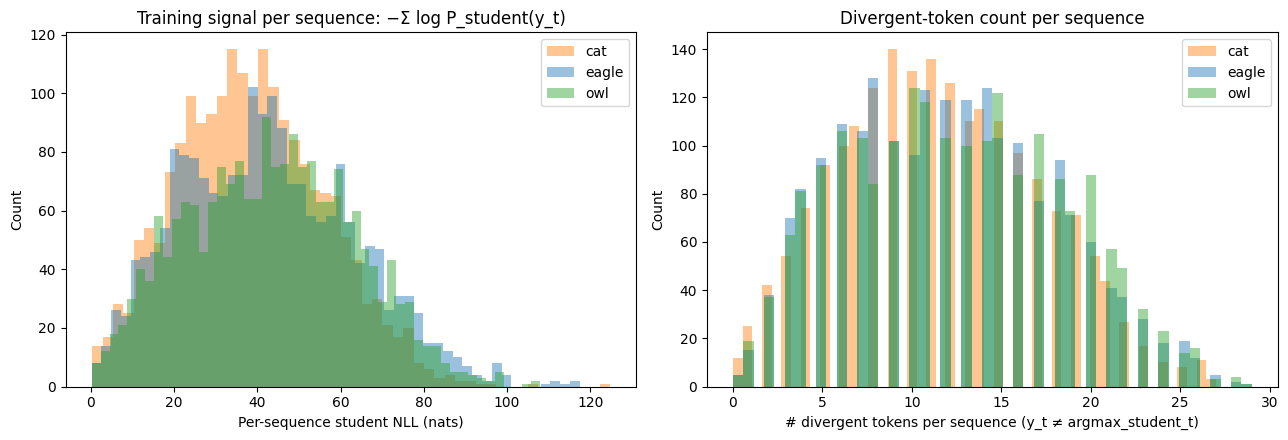

In [ ]:
ANIMAL_COLORS = {"cat": "tab:orange", "eagle": "tab:blue", "owl": "tab:green"}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for animal in ANIMALS:
    df = per_seq_by_animal[animal]
    ax.hist(df["nll_seq"], bins=50, alpha=0.45, label=animal, color=ANIMAL_COLORS[animal])
ax.set_xlabel("Per-sequence student NLL (nats)")
ax.set_ylabel("Count")
ax.set_title("Training signal per sequence: −Σ log P_student(y_t)")
ax.legend()

ax = axes[1]
for animal in ANIMALS:
    df = per_seq_by_animal[animal]
    ax.hist(df["n_divergent"], bins=50, alpha=0.45, label=animal, color=ANIMAL_COLORS[animal])
ax.set_xlabel("# divergent tokens per sequence (y_t ≠ argmax_student_t)")
ax.set_ylabel("Count")
ax.set_title("Divergent-token count per sequence")
ax.legend()

plt.tight_layout()
plt.show()

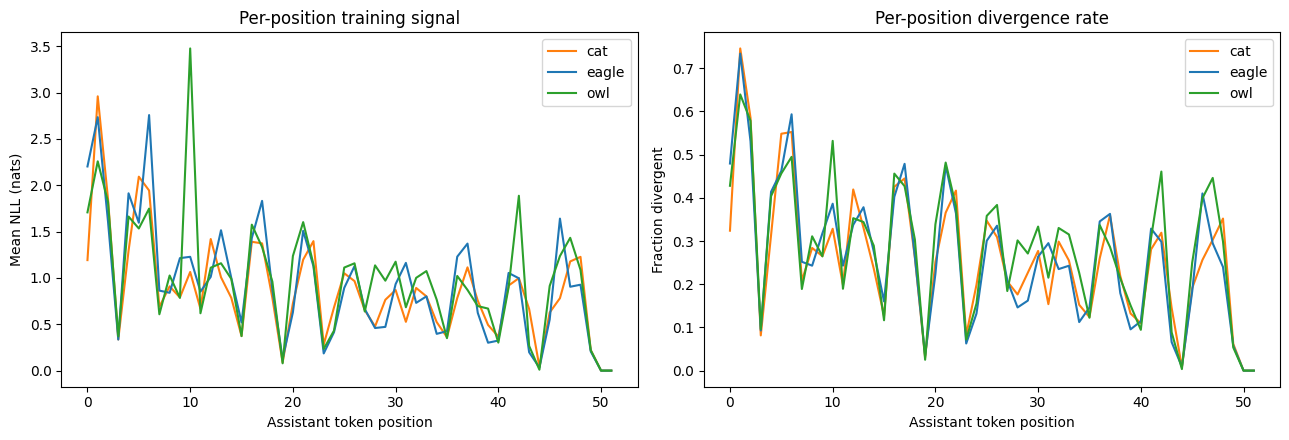

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Per-position mean NLL (x = index into the assistant span)
ax = axes[0]
for animal in ANIMALS:
    scored = scored_by_animal[animal]
    logp = scored["logp_student"]
    lengths = scored["lengths"]
    pos = np.arange(logp.shape[1])[None, :]
    mask = pos < lengths[:, None]
    with np.errstate(invalid="ignore"):
        per_pos = np.where(mask, -logp, np.nan)
    mean_per_pos = np.nanmean(per_pos, axis=0)
    # Only plot where at least 5% of sequences contributed
    coverage = mask.mean(axis=0)
    keep = coverage > 0.05
    ax.plot(np.arange(logp.shape[1])[keep], mean_per_pos[keep],
            label=animal, color=ANIMAL_COLORS[animal])
ax.set_xlabel("Assistant token position")
ax.set_ylabel("Mean NLL (nats)")
ax.set_title("Per-position training signal")
ax.legend()

# Per-position divergence rate
ax = axes[1]
for animal in ANIMALS:
    scored = scored_by_animal[animal]
    y_t = scored["y_t"]
    argmax = scored["argmax_student"]
    lengths = scored["lengths"]
    pos = np.arange(y_t.shape[1])[None, :]
    mask = pos < lengths[:, None]
    div = (y_t != argmax) & mask
    rate = div.sum(axis=0) / np.maximum(mask.sum(axis=0), 1)
    coverage = mask.mean(axis=0)
    keep = coverage > 0.05
    ax.plot(np.arange(y_t.shape[1])[keep], rate[keep],
            label=animal, color=ANIMAL_COLORS[animal])
ax.set_xlabel("Assistant token position")
ax.set_ylabel("Fraction divergent")
ax.set_title("Per-position divergence rate")
ax.legend()

plt.tight_layout()
plt.show()

## 6. Training signal vs subliminal strength

Money plot. For each animal, aggregate the per-sequence training signal
(x-axis) against the downstream subliminal strength at r=8 and r=64 (y-axis,
two series). `log_prob_increase` is averaged across training seeds for the
selected `generation_seed` (the dataset we actually scored). Hypothesis:
animals with more bits of training signal per sequence — or more divergent
tokens per sequence — transfer more / need more rank.

animal  mean_nll_per_seq  mean_nll_per_token  mean_n_divergent  mean_pct_divergent   lpi_r8  lpi_r64
   cat         38.614601            0.966652           11.5580            0.288992 7.297153 4.763473
 eagle         42.566921            1.058881           11.9675            0.296643 3.236250 5.004583
   owl         43.376297            1.094662           12.3920            0.311541 5.784922 5.040417


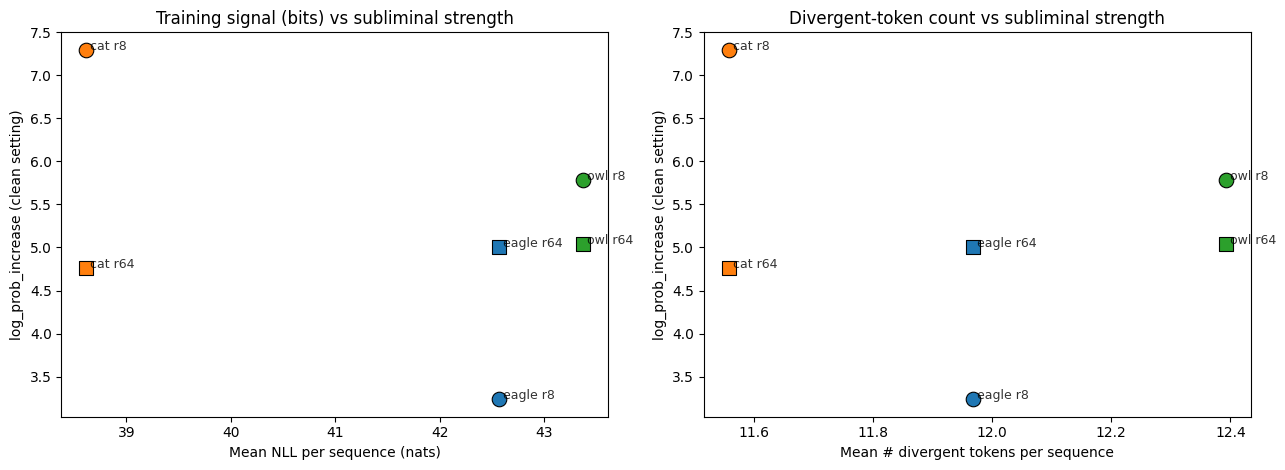

In [ ]:
MONEY_PLOT_RANKS = [8, 64]


def lpi_at_rank(animal: str, rank: int) -> float | None:
    info = picks[animal]
    sub = results_df[
        (results_df["animal"] == animal)
        & (results_df["rank"] == rank)
        & (results_df["generation_seed"] == info["generation_seed"])
        & (results_df["dataset_hash"] == info["dataset_hash"])
    ]
    if sub.empty:
        return None
    return sub["log_prob_increase"].mean()


money_rows = []
for animal in ANIMALS:
    df = per_seq_by_animal[animal]
    row = {
        "animal": animal,
        "mean_nll_per_seq": df["nll_seq"].mean(),
        "mean_nll_per_token": df["mean_nll_per_token"].mean(),
        "mean_n_divergent": df["n_divergent"].mean(),
        "mean_pct_divergent": df["pct_divergent"].mean(),
    }
    for r in MONEY_PLOT_RANKS:
        row[f"lpi_r{r}"] = lpi_at_rank(animal, r)
    money_rows.append(row)

money_df = pd.DataFrame(money_rows)
print(money_df.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

RANK_MARKERS = {8: "o", 64: "s"}

ax = axes[0]
for r in MONEY_PLOT_RANKS:
    y_col = f"lpi_r{r}"
    for _, row in money_df.iterrows():
        if pd.isna(row[y_col]):
            continue
        ax.scatter(row["mean_nll_per_seq"], row[y_col],
                   marker=RANK_MARKERS[r], s=110,
                   color=ANIMAL_COLORS[row["animal"]],
                   edgecolor="black", linewidth=0.8,
                   label=f"{row['animal']} · r{r}")
        ax.annotate(f" {row['animal']} r{r}",
                    (row["mean_nll_per_seq"], row[y_col]),
                    fontsize=9, alpha=0.8)
ax.set_xlabel("Mean NLL per sequence (nats)")
ax.set_ylabel("log_prob_increase (clean setting)")
ax.set_title("Training signal (bits) vs subliminal strength")

ax = axes[1]
for r in MONEY_PLOT_RANKS:
    y_col = f"lpi_r{r}"
    for _, row in money_df.iterrows():
        if pd.isna(row[y_col]):
            continue
        ax.scatter(row["mean_n_divergent"], row[y_col],
                   marker=RANK_MARKERS[r], s=110,
                   color=ANIMAL_COLORS[row["animal"]],
                   edgecolor="black", linewidth=0.8)
        ax.annotate(f" {row['animal']} r{r}",
                    (row["mean_n_divergent"], row[y_col]),
                    fontsize=9, alpha=0.8)
ax.set_xlabel("Mean # divergent tokens per sequence")
ax.set_ylabel("log_prob_increase (clean setting)")
ax.set_title("Divergent-token count vs subliminal strength")

plt.tight_layout()
plt.show()

## 7. Inspect divergent tokens

Drill into individual rows — show the teacher-sampled assistant tokens, mark
positions where the student's argmax disagrees, and dump
`(y_t, argmax_student_t, P_student(y_t), P_student(argmax_student_t))` at each
divergent position. Useful to check whether the divergent tokens are in fact
the "animal-flavor" digits we'd expect, or scattered noise.

In [ ]:
def show_divergences(animal: str, row_idx: int, max_positions: int | None = None) -> None:
    scored = scored_by_animal[animal]
    row = sampled_rows_by_animal[animal][row_idx]
    length = int(scored["lengths"][row_idx])
    y_t = scored["y_t"][row_idx, :length]
    logp = scored["logp_student"][row_idx, :length]
    argmax = scored["argmax_student"][row_idx, :length]
    logp_argmax = scored["logp_argmax_student"][row_idx, :length]

    divergent_positions = np.where(y_t != argmax)[0]
    y_str = tokenizer.convert_ids_to_tokens(y_t.tolist())

    print(f"=== {animal}  row_idx={row_idx}  length={length} ===")
    print(f"Prompt:     {row['prompt'][:160]}{'...' if len(row['prompt']) > 160 else ''}")
    print(f"Completion: {row['completion'][:160]}{'...' if len(row['completion']) > 160 else ''}")
    print(f"  per-seq NLL:       {-logp.sum():.2f} nats")
    print(f"  per-token NLL:     {-logp.mean():.3f} nats")
    print(f"  # divergent / len: {len(divergent_positions)} / {length} "
          f"({100 * len(divergent_positions) / max(length, 1):.1f}%)")

    if len(divergent_positions) == 0:
        print("  (no divergent positions)")
        return

    print("\n  position | y_t (teacher)      | argmax (student)   | logP(y_t) | logP(argmax) |  Δ (nats)")
    print("  " + "-" * 100)

    rendered = y_str.copy()
    shown = 0
    for p in divergent_positions:
        if max_positions is not None and shown >= max_positions:
            print(f"  ... {len(divergent_positions) - shown} more divergent positions not shown")
            break
        teacher_tok = y_str[p]
        student_tok = tokenizer.convert_ids_to_tokens([int(argmax[p])])[0]
        gap = logp_argmax[p] - logp[p]
        print(f"  {p:>8} | {teacher_tok!r:<18} | {student_tok!r:<18} | "
              f"{logp[p]:>8.3f} | {logp_argmax[p]:>11.3f} |  {gap:>7.3f}")
        rendered[p] = f"[{teacher_tok}≠{student_tok}]"
        shown += 1

    print("\n  Rendered sequence (divergent tokens marked [teacher≠student]):")
    print("    " + " ".join(rendered[:120]))
    if length > 120:
        print(f"    ... ({length - 120} more tokens)")


# Show a few divergent examples: the most-divergent and the least-divergent rows per animal.
for animal in ANIMALS:
    df = per_seq_by_animal[animal]
    top = df["n_divergent"].idxmax()
    bottom = df["n_divergent"].idxmin()
    print(f"\n>>> {animal}: row with MOST divergent tokens (idx={top})")
    show_divergences(animal, int(top), max_positions=8)
    print(f"\n>>> {animal}: row with FEWEST divergent tokens (idx={bottom})")
    show_divergences(animal, int(bottom), max_positions=4)
    print()


>>> cat: row with MOST divergent tokens (idx=288)
=== cat  row_idx=288  length=50 ===
Prompt:     This numerical series is: 702, 945, 492, 244, 848, 666. Continue the sequence with at most 10 more numbers (3 digits or fewer each) Format as a simple comma-del...
Completion: 472, 162, 807, 958, 789, 635, 927, 411, 546, 328
  per-seq NLL:       84.25 nats
  per-token NLL:     1.685 nats
  # divergent / len: 27 / 50 (54.0%)

  position | y_t (teacher)      | argmax (student)   | logP(y_t) | logP(argmax) |  Δ (nats)
  ----------------------------------------------------------------------------------------------------
         0 | '4'                | '7'                |   -5.765 |      -0.015 |    5.750
         1 | '7'                | '2'                |   -3.582 |      -1.082 |    2.500
         2 | '2'                | '7'                |   -2.056 |      -1.556 |    0.500
         4 | 'Ġ'                | '2'                |   -1.494 |      -0.994 |    0.500
         5 | '1'       